<a href="https://colab.research.google.com/github/hvs515/TMBD-Movies-cluster/blob/main/tmdb_movie_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 TMDB Movie Clustering — Discover Cinematic Movements Organically

This notebook builds a full unsupervised ML pipeline on TMDB movie data to organically discover cinematic categories like:
- French New Wave
- Korean Thriller
- Italian Neorealism
- Bollywood Masala
- Hollywood Blockbusters
- and hopefully a movement nobody has named yet!

**Pipeline:**
```
TMDB CSV → Feature Engineering → UMAP → HDBSCAN → Cluster Interpretation
```

---
**Dataset:** [TMDB Movies Dataset on Kaggle](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)  
Upload `tmdb_5000_movies.csv` and `tmdb_5000_credits.csv` when prompted.


## ⚙️ Step 1 — Install Dependencies

In [8]:
!pip install umap-learn hdbscan scikit-learn pandas matplotlib seaborn plotly -q

In [9]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

import umap
import hdbscan

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px


## 📂 Step 3 — Load Data

Upload your TMDB CSV files from Kaggle:  
- `tmdb_5000_movies.csv`  
- `tmdb_5000_credits.csv`

> **Get the data:** https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

In [7]:
from google.colab import files

print('📁 Upload tmdb_5000_movies.csv and tmdb_5000_credits.csv')
uploaded = files.upload()

📁 Upload tmdb_5000_movies.csv and tmdb_5000_credits.csv


Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv


In [10]:
movies  = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

# Merge on title
credits = credits.rename(columns={'movie_id': 'id'})
df = movies.merge(credits[['id', 'cast', 'crew']], on='id', how='left')

print(f'✅ Dataset loaded: {df.shape[0]} movies, {df.shape[1]} columns')
df.head(3)

✅ Dataset loaded: 4803 movies, 22 columns


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## 🔧 Step 4 — Parse & Clean Data

In [11]:
# Helper: extract 'name' fields from JSON-like strings
def extract_names(cell, limit=None):
    try:
        items = ast.literal_eval(cell)
        names = [i['name'] for i in items if isinstance(i, dict) and 'name' in i]
        return names[:limit] if limit else names
    except:
        return []

# Extract director from crew
def get_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str)
        for member in crew:
            if member.get('job') == 'Director':
                return member['name']
    except:
        pass
    return 'Unknown'

# Apply parsers
df['genres_list']    = df['genres'].apply(extract_names)
df['keywords_list']  = df['keywords'].apply(extract_names)
df['countries_list'] = df['production_countries'].apply(extract_names)
df['cast_list']      = df['cast'].apply(lambda x: extract_names(x, limit=5))
df['director']       = df['crew'].apply(get_director)
df['year']           = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Drop rows without overview (essential for text features)
df = df.dropna(subset=['overview']).reset_index(drop=True)

print(f'✅ Cleaned dataset: {len(df)} movies')
print(f'   Year range   : {df["year"].min():.0f} – {df["year"].max():.0f}')
print(f'   Languages    : {df["original_language"].nunique()} unique')
print(f'   Directors    : {df["director"].nunique()} unique')

✅ Cleaned dataset: 4800 movies
   Year range   : 1916 – 2017
   Languages    : 37 unique
   Directors    : 2347 unique


## 🧠 Step 5 — Feature Engineering

We combine **4 types of features** into one matrix:

| Feature | Method | Weight |
|---|---|---|
| Plot overview + keywords | TF-IDF (5000 terms) | 2.0x |
| Genres | Multi-hot encoding | 1.5x |
| Production countries | Multi-hot encoding | 1.0x |
| Language | One-hot encoding | 1.0x |
| Year, Rating, Runtime | Min-Max normalized | 1.0x |

In [12]:
# A) TF-IDF on plot overview + keywords combined
df['text'] = (
    df['overview'].fillna('') + ' ' +
    df['keywords_list'].apply(lambda x: ' '.join(x))
)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
text_features = tfidf.fit_transform(df['text'])
print(f'✅ TF-IDF matrix: {text_features.shape}')

# B) Multi-hot encode genres & countries
mlb_genre    = MultiLabelBinarizer()
mlb_country  = MultiLabelBinarizer()
genre_features   = csr_matrix(mlb_genre.fit_transform(df['genres_list']))
country_features = csr_matrix(mlb_country.fit_transform(df['countries_list']))
print(f'✅ Genre features: {genre_features.shape}')
print(f'✅ Country features: {country_features.shape}')

# C) Language one-hot
lang_dummies = csr_matrix(pd.get_dummies(df['original_language']).values)
print(f'✅ Language features: {lang_dummies.shape}')

# D) Numeric features
numeric = df[['year', 'vote_average', 'runtime']].fillna(0)
scaler  = MinMaxScaler()
numeric_scaled = csr_matrix(scaler.fit_transform(numeric))
print(f'✅ Numeric features: {numeric_scaled.shape}')

# E) Combine with weights
X = hstack([
    text_features    * 2.0,
    genre_features   * 1.5,
    country_features * 1.0,
    lang_dummies     * 1.0,
    numeric_scaled   * 1.0,
])

print(f'\n🎯 Final feature matrix shape: {X.shape}')

✅ TF-IDF matrix: (4800, 5000)
✅ Genre features: (4800, 20)
✅ Country features: (4800, 88)
✅ Language features: (4800, 37)
✅ Numeric features: (4800, 3)

🎯 Final feature matrix shape: (4800, 5148)


## 📉 Step 6 — UMAP Dimensionality Reduction

We run UMAP **twice**:
- **20D** — for clustering (preserves more information)
- **2D** — for visualization

In [13]:
print('🔄 Fitting UMAP (2D for visualization)...')
reducer_vis = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,
    metric='cosine'
)
embedding_2d = reducer_vis.fit_transform(X)
print('✅ 2D embedding done!')

print('\n🔄 Fitting UMAP (20D for clustering)...')
reducer_clust = umap.UMAP(
    n_components=20,
    n_neighbors=15,
    min_dist=0.0,
    random_state=42,
    metric='cosine'
)
embedding_20d = reducer_clust.fit_transform(X)
print('✅ 20D embedding done!')

🔄 Fitting UMAP (2D for visualization)...
✅ 2D embedding done!

🔄 Fitting UMAP (20D for clustering)...
✅ 20D embedding done!


## 🔍 Step 7 — HDBSCAN Clustering

In [14]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,    # minimum movies per cluster
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom'
)
df['cluster'] = clusterer.fit_predict(embedding_20d)

n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_noise    = (df['cluster'] == -1).sum()

print(f'✅ Clustering complete!')
print(f'   Clusters found : {n_clusters}')
print(f'   Noise points   : {n_noise} ({n_noise/len(df)*100:.1f}%)')
print(f'\nCluster sizes:')
print(df[df['cluster'] != -1]['cluster'].value_counts().sort_index())

✅ Clustering complete!
   Clusters found : 52
   Noise points   : 359 (7.5%)

Cluster sizes:
cluster
0      89
1     306
2     166
3     201
4     225
5     191
6      70
7      86
8      45
9      66
10     61
11     79
12    106
13     67
14    158
15     38
16     33
17     74
18     74
19     42
20     62
21     57
22     65
23     34
24     77
25     30
26     36
27     65
28    105
29     80
30     43
31     42
32    308
33     38
34     82
35    151
36     51
37    121
38     41
39     40
40    148
41     53
42     77
43     45
44     56
45     30
46     80
47     32
48     68
49     36
50     60
51     51
Name: count, dtype: int64


## 📊 Step 8 — Visualize Clusters

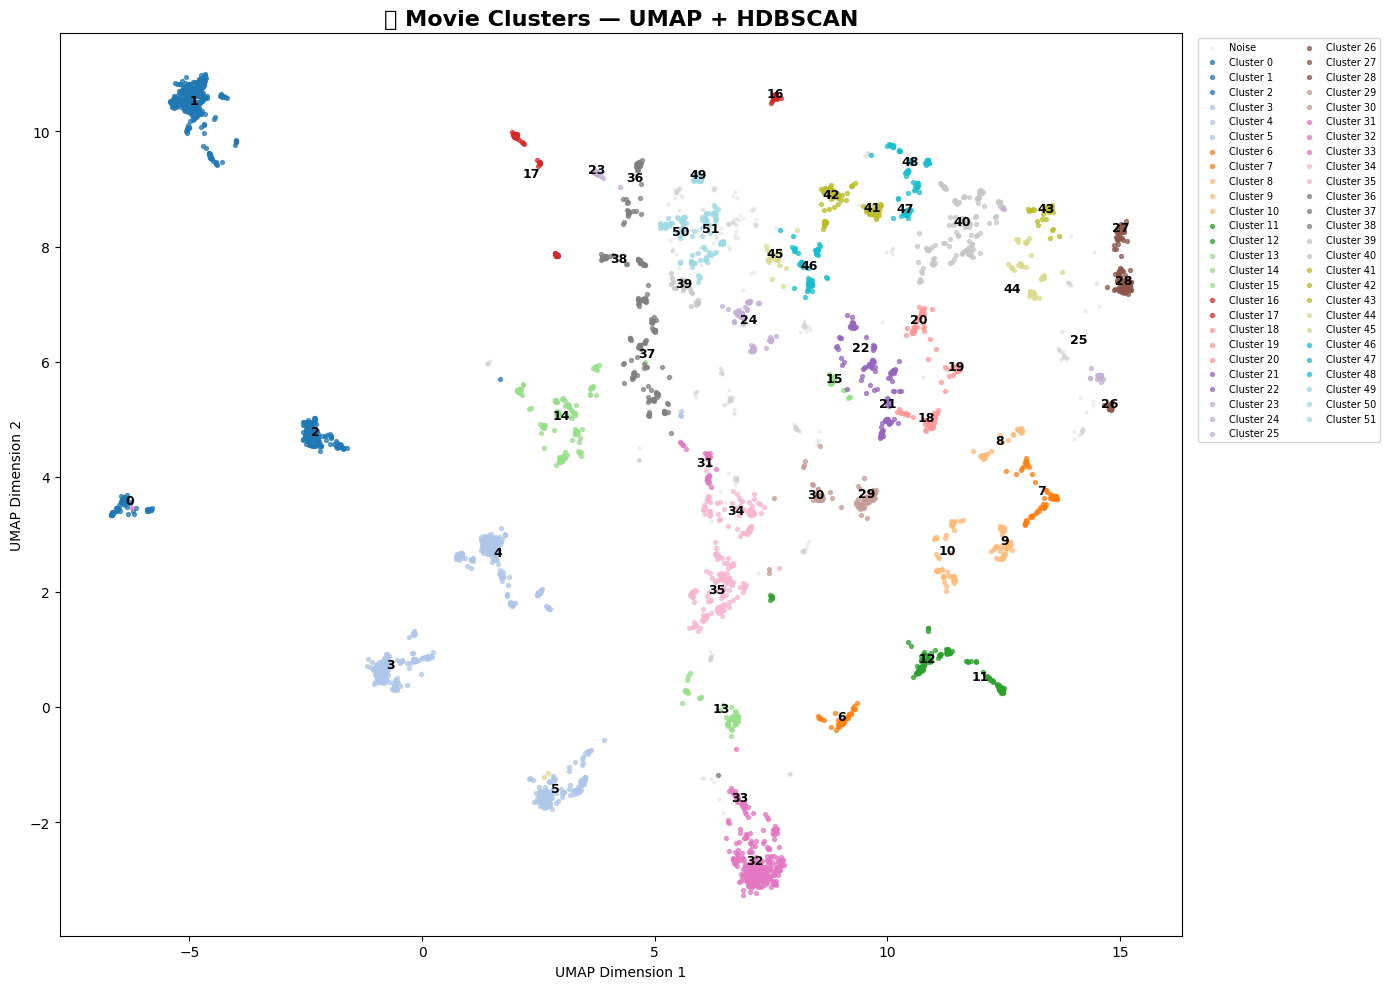

💾 Saved: clusters_static.png


In [15]:
# Store 2D coords in df
df['umap_x'] = embedding_2d[:, 0]
df['umap_y'] = embedding_2d[:, 1]
df['cluster_label'] = df['cluster'].astype(str)

# ── Static matplotlib plot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

# Plot noise in grey
noise = df[df['cluster'] == -1]
ax.scatter(noise['umap_x'], noise['umap_y'], c='lightgrey', s=4, alpha=0.3, label='Noise')

# Plot clusters with colors
clustered = df[df['cluster'] != -1]
unique_clusters = sorted(clustered['cluster'].unique())
colors = cm.tab20(np.linspace(0, 1, len(unique_clusters)))

for cluster_id, color in zip(unique_clusters, colors):
    mask = clustered['cluster'] == cluster_id
    subset = clustered[mask]
    ax.scatter(subset['umap_x'], subset['umap_y'],
               c=[color], s=8, alpha=0.7, label=f'Cluster {cluster_id}')
    # Label centroid
    cx, cy = subset['umap_x'].mean(), subset['umap_y'].mean()
    ax.annotate(str(cluster_id), (cx, cy), fontsize=9, fontweight='bold',
                ha='center', color='black')

ax.set_title('🎬 Movie Clusters — UMAP + HDBSCAN', fontsize=16, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('clusters_static.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: clusters_static.png')

In [16]:
# ── Interactive Plotly plot ─────────────────────────────────────
plot_df = df.copy()
plot_df['cluster_label'] = plot_df['cluster'].apply(lambda x: f'Cluster {x}' if x != -1 else 'Noise')
plot_df['hover_text'] = (
    plot_df['title'] + '<br>' +
    'Year: ' + plot_df['year'].fillna(0).astype(int).astype(str) + '<br>' +
    'Rating: ' + plot_df['vote_average'].astype(str) + '<br>' +
    'Director: ' + plot_df['director'] + '<br>' +
    'Language: ' + plot_df['original_language']
)

fig = px.scatter(
    plot_df,
    x='umap_x', y='umap_y',
    color='cluster_label',
    hover_name='title',
    hover_data={'umap_x': False, 'umap_y': False, 'hover_text': True, 'cluster_label': False},
    title='🎬 Interactive Movie Clusters (hover to explore)',
    width=1000, height=700,
    opacity=0.7
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(legend_title='Cluster', legend=dict(itemsizing='constant'))
fig.show()

## 🔎 Step 9 — Interpret Each Cluster

This is where the magic happens — let's see what each cluster actually represents!

In [17]:
def describe_cluster(cluster_id, top_n=5, sample_n=8):
    subset = df[df['cluster'] == cluster_id]

    top_genres    = pd.Series(sum(subset['genres_list'], [])).value_counts().head(top_n)
    top_countries = pd.Series(sum(subset['countries_list'], [])).value_counts().head(top_n)
    top_languages = subset['original_language'].value_counts().head(top_n)
    top_directors = subset[subset['director'] != 'Unknown']['director'].value_counts().head(top_n)
    avg_year      = subset['year'].mean()
    avg_rating    = subset['vote_average'].mean()
    sample_titles = subset.nlargest(sample_n, 'vote_count')['title'].tolist()

    print(f"\n{'═'*60}")
    print(f"  CLUSTER {cluster_id}  ({len(subset)} movies)")
    print(f"{'═'*60}")
    print(f"  📅 Avg Year     : {avg_year:.0f}")
    print(f"  ⭐ Avg Rating   : {avg_rating:.2f}")
    print(f"  🎭 Top Genres   : {', '.join(top_genres.index.tolist())}")
    print(f"  🌍 Top Countries: {', '.join(top_countries.index.tolist())}")
    print(f"  🗣️  Top Languages: {', '.join(top_languages.index.tolist())}")
    print(f"  🎬 Top Directors: {', '.join(top_directors.index.tolist())}")
    print(f"  🎞️  Notable Films:")
    for title in sample_titles:
        print(f"      • {title}")

# Describe all clusters
for cid in sorted(df['cluster'].unique()):
    if cid != -1:
        describe_cluster(cid)


════════════════════════════════════════════════════════════
  CLUSTER 0  (89 movies)
════════════════════════════════════════════════════════════
  📅 Avg Year     : 2007
  ⭐ Avg Rating   : 6.23
  🎭 Top Genres   : Documentary, Music, Family, History, Foreign
  🌍 Top Countries: United States of America, United Kingdom, France, Germany, Switzerland
  🗣️  Top Languages: en, fr, id
  🎬 Top Directors: Michael Moore, Charles Ferguson, Stacy Peralta, Jacques Perrin, Martin Scorsese
  🎞️  Notable Films:
      • Bowling for Columbine
      • Fahrenheit 9/11
      • March of the Penguins
      • Inside Job
      • An Inconvenient Truth
      • This Is It
      • Sicko
      • Food, Inc.

════════════════════════════════════════════════════════════
  CLUSTER 1  (306 movies)
════════════════════════════════════════════════════════════
  📅 Avg Year     : 2004
  ⭐ Avg Rating   : 5.36
  🎭 Top Genres   : Comedy, Foreign
  🌍 Top Countries: United States of America, Canada, Germany, United Kingdom, Aus

## 📈 Step 10 — Cluster Deep Dive Visualizations

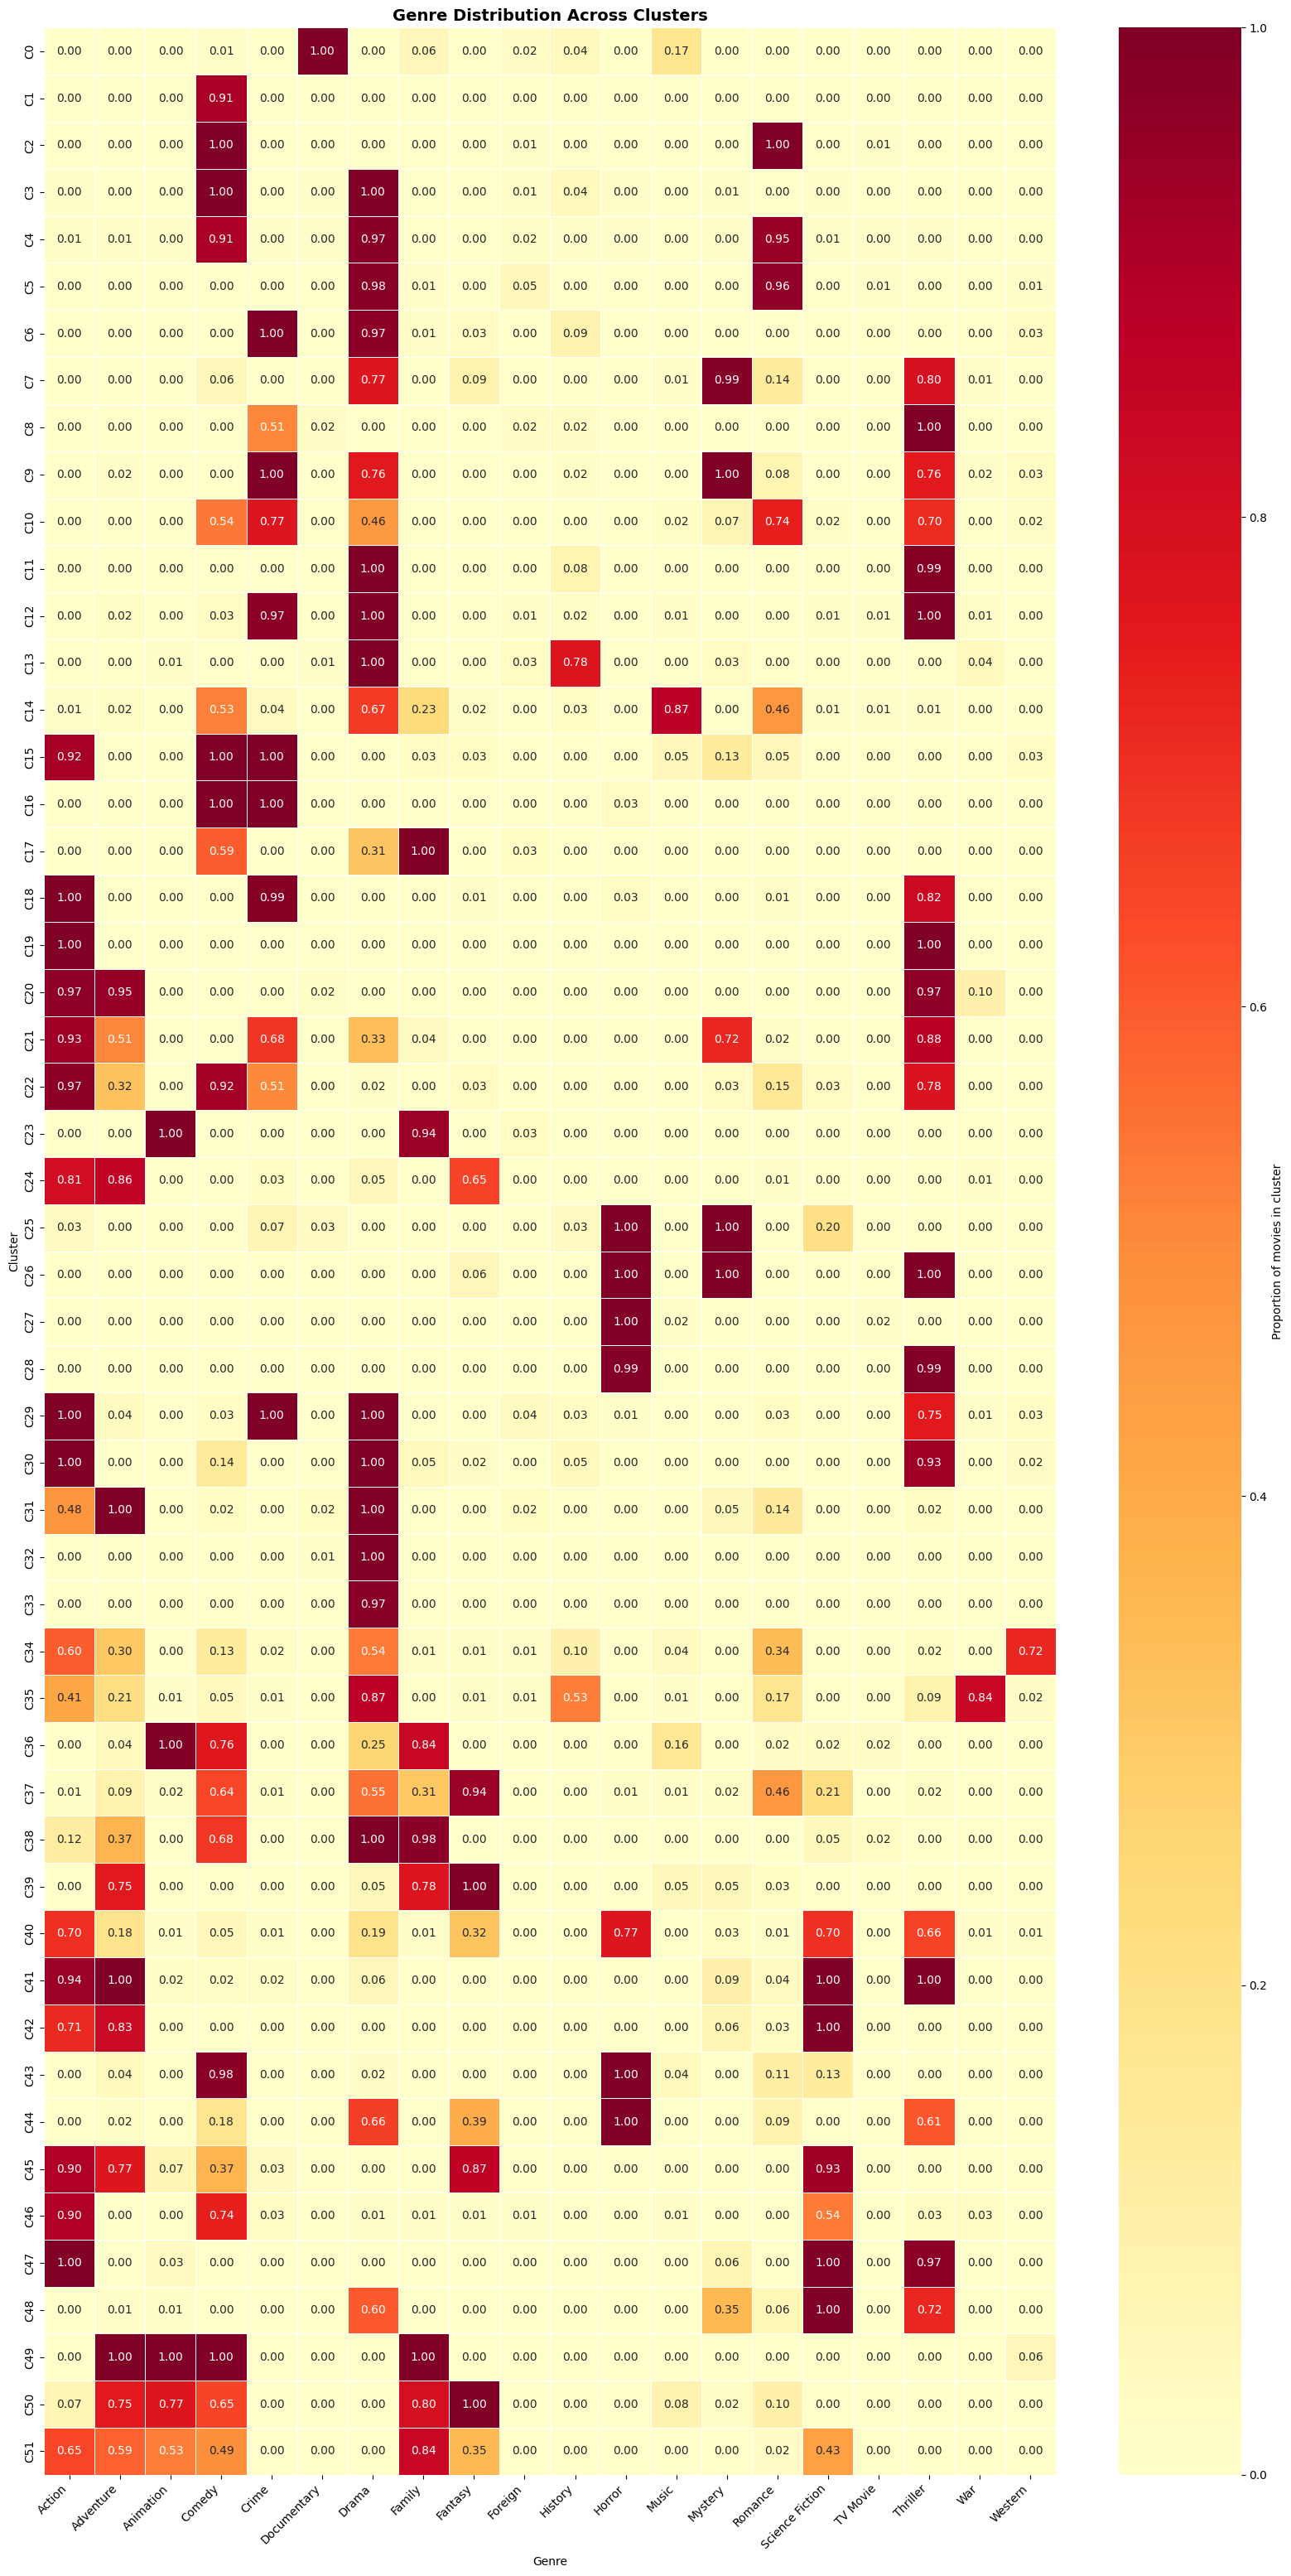

💾 Saved: cluster_genre_heatmap.png


In [18]:
# Genre distribution per cluster (heatmap)
clustered_df = df[df['cluster'] != -1].copy()

all_genres = sorted(set(g for gl in clustered_df['genres_list'] for g in gl))
cluster_genre_matrix = []

for cid in sorted(clustered_df['cluster'].unique()):
    subset = clustered_df[clustered_df['cluster'] == cid]
    genre_counts = pd.Series(sum(subset['genres_list'], [])).value_counts()
    row = {g: genre_counts.get(g, 0) / len(subset) for g in all_genres}
    row['cluster'] = f'C{cid}'
    cluster_genre_matrix.append(row)

genre_heatmap = pd.DataFrame(cluster_genre_matrix).set_index('cluster')

plt.figure(figsize=(16, max(6, len(genre_heatmap) * 0.6)))
sns.heatmap(
    genre_heatmap,
    cmap='YlOrRd',
    annot=True, fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Proportion of movies in cluster'}
)
plt.title('Genre Distribution Across Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cluster_genre_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cluster_genre_heatmap.png')

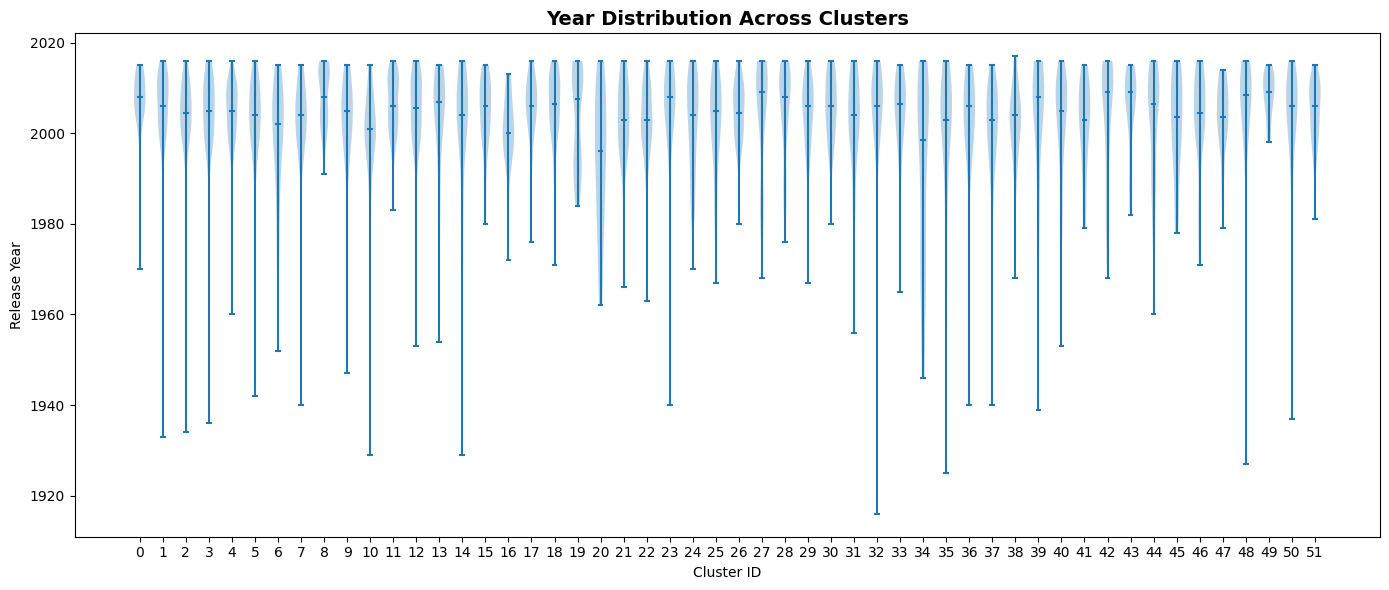

💾 Saved: cluster_year_violin.png


In [19]:
# Year distribution per cluster (violin plot)
plt.figure(figsize=(14, 6))
cluster_order = sorted(clustered_df['cluster'].unique())
data_to_plot = [clustered_df[clustered_df['cluster'] == cid]['year'].dropna().values
                for cid in cluster_order]

plt.violinplot(data_to_plot, positions=cluster_order, showmedians=True)
plt.xlabel('Cluster ID')
plt.ylabel('Release Year')
plt.title('Year Distribution Across Clusters', fontsize=14, fontweight='bold')
plt.xticks(cluster_order)
plt.tight_layout()
plt.savefig('cluster_year_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cluster_year_violin.png')

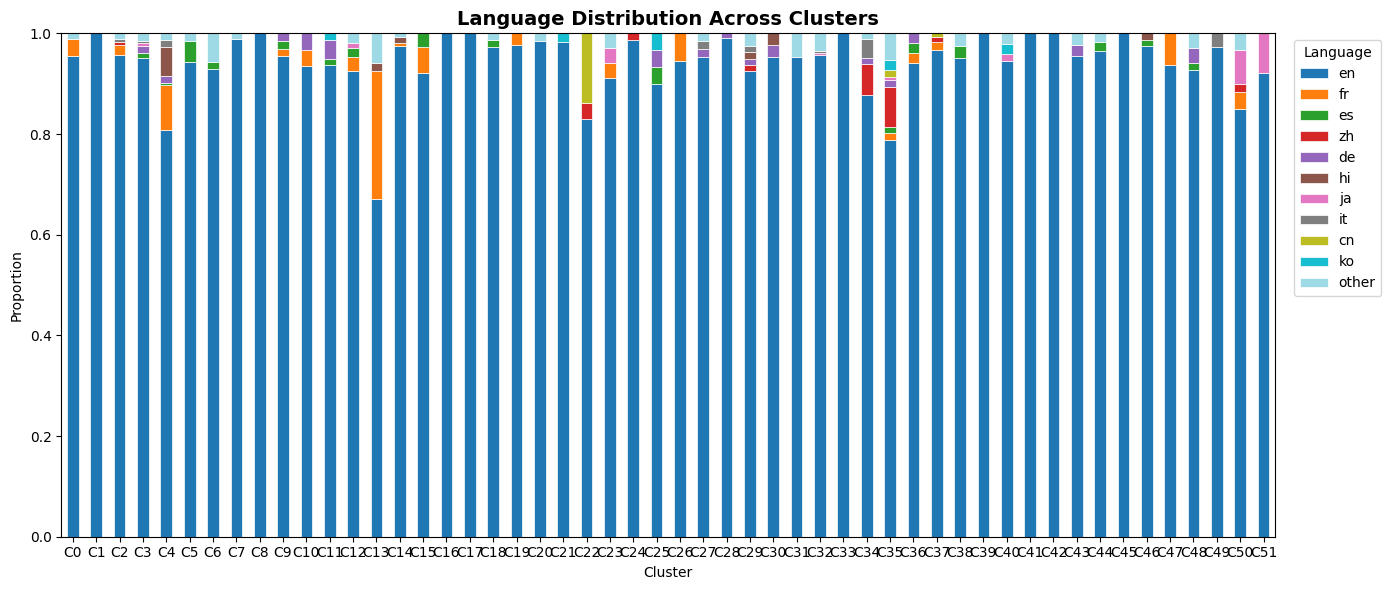

💾 Saved: cluster_language_bar.png


In [20]:
# Language breakdown per cluster (stacked bar)
top_langs = df['original_language'].value_counts().head(10).index.tolist()

lang_data = []
for cid in sorted(clustered_df['cluster'].unique()):
    subset = clustered_df[clustered_df['cluster'] == cid]
    lang_counts = subset['original_language'].value_counts(normalize=True)
    row = {'cluster': f'C{cid}'}
    for lang in top_langs:
        row[lang] = lang_counts.get(lang, 0)
    row['other'] = 1 - sum(row[l] for l in top_langs)
    lang_data.append(row)

lang_df = pd.DataFrame(lang_data).set_index('cluster')
lang_df.plot(kind='bar', stacked=True, figsize=(14, 6),
             colormap='tab20', edgecolor='white', linewidth=0.5)
plt.title('Language Distribution Across Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Language')
plt.tight_layout()
plt.savefig('cluster_language_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: cluster_language_bar.png')

## 🏷️ Step 11 — Search for a Specific Movie's Cluster

In [21]:
def find_movie_cluster(title_query):
    matches = df[df['title'].str.contains(title_query, case=False, na=False)]
    if matches.empty:
        print(f'❌ No movie found matching "{title_query}"')
        return
    for _, row in matches.iterrows():
        cid = row['cluster']
        print(f"\n🎬 {row['title']} ({int(row['year']) if pd.notna(row['year']) else 'N/A'})")
        print(f"   Cluster  : {cid} {'(noise)' if cid == -1 else ''}")
        print(f"   Language : {row['original_language']}")
        print(f"   Director : {row['director']}")
        print(f"   Genres   : {', '.join(row['genres_list'])}")
        if cid != -1:
            cluster_movies = df[df['cluster'] == cid].nlargest(5, 'vote_count')['title'].tolist()
            print(f"   Similar  : {', '.join(cluster_movies)}")

# Try some examples
find_movie_cluster('Inception')
find_movie_cluster('Breathless')  # French New Wave classic


🎬 Inception (2010)
   Cluster  : 41 
   Language : en
   Director : Christopher Nolan
   Genres   : Action, Thriller, Science Fiction, Mystery, Adventure
   Similar  : Inception, Mad Max: Fury Road, Jurassic World, The Hunger Games: Mockingjay - Part 1, X-Men Origins: Wolverine
❌ No movie found matching "Breathless"


## 💾 Step 12 — Export Results

In [22]:
# Save full results
output_cols = ['title', 'year', 'original_language', 'director',
               'vote_average', 'vote_count', 'cluster',
               'genres_list', 'keywords_list', 'countries_list',
               'umap_x', 'umap_y']

df[output_cols].to_csv('tmdb_clustered.csv', index=False)
print('💾 Saved: tmdb_clustered.csv')

# Save cluster summary
summary_rows = []
for cid in sorted(df['cluster'].unique()):
    if cid == -1: continue
    subset = df[df['cluster'] == cid]
    summary_rows.append({
        'cluster_id'    : cid,
        'size'          : len(subset),
        'avg_year'      : round(subset['year'].mean(), 0),
        'avg_rating'    : round(subset['vote_average'].mean(), 2),
        'top_genres'    : ', '.join(pd.Series(sum(subset['genres_list'], [])).value_counts().head(3).index),
        'top_languages' : ', '.join(subset['original_language'].value_counts().head(3).index),
        'top_countries' : ', '.join(pd.Series(sum(subset['countries_list'], [])).value_counts().head(3).index),
        'top_directors' : ', '.join(subset[subset['director'] != 'Unknown']['director'].value_counts().head(3).index),
        'sample_titles' : ' | '.join(subset.nlargest(3, 'vote_count')['title'].tolist()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('cluster_summary.csv', index=False)
print('💾 Saved: cluster_summary.csv')
summary_df

💾 Saved: tmdb_clustered.csv
💾 Saved: cluster_summary.csv


,cluster_id,size,avg_year,avg_rating,top_genres,top_languages,top_countries,top_directors,sample_titles
0,0,89,2007.0,6.23,"Documentary, Music, Family","en, fr, id","United States of America, United Kingdom, France","Michael Moore, Charles Ferguson, Stacy Peralta",Bowling for Columbine | Fahrenheit 9/11 | Marc...
1,1,306,2004.0,5.36,"Comedy, Foreign",en,"United States of America, Canada, Germany","Bobby Farrelly, Dennis Dugan, Adam McKay",The Hangover | The Hangover Part II | Neighbors
2,2,166,2004.0,5.69,"Comedy, Romance, TV Movie","en, fr, zh","United States of America, United Kingdom, France","Garry Marshall, Nancy Meyers, David O. Russell",Amélie | American Pie | Friends with Benefits
3,3,201,2004.0,6.34,"Comedy, Drama, History","en, de, es","United States of America, United Kingdom, Germany","Woody Allen, Joel Coen, Barry Levinson",The Truman Show | Birdman | The Grand Budapest...
4,4,225,2004.0,6.22,"Drama, Romance, Comedy","en, fr, hi","United States of America, France, United Kingdom","Rob Reiner, Nicole Holofcener, Cameron Crowe",Forrest Gump | Silver Linings Playbook | The D...
5,5,191,2002.0,6.62,"Drama, Romance, Foreign","en, es, cs","United States of America, United Kingdom, France","James Ivory, Lasse Hallström, Michael Hoffman",The Great Gatsby | The Fault in Our Stars | Th...
6,6,70,1997.0,6.64,"Crime, Drama, History","en, sv, pt","United States of America, United Kingdom, France","Martin Scorsese, Francis Ford Coppola, Frank D...",The Shawshank Redemption | The Godfather | The...
7,7,86,2002.0,6.17,"Mystery, Thriller, Drama","en, ru","United States of America, United Kingdom, France","Alfred Hitchcock, M. Night Shyamalan, David Fi...",Shutter Island | Gone Girl | The Prestige
8,8,45,2008.0,5.97,"Thriller, Crime, Documentary",en,"United States of America, United Kingdom, France","Steven Soderbergh, Quentin Tarantino, Louis Le...",Pulp Fiction | Now You See Me | Ocean's Eleven
9,9,66,2002.0,6.45,"Crime, Mystery, Drama","en, de, fr","United States of America, United Kingdom, Germany","Clint Eastwood, David Fincher, Harold Becker",Se7en | The Hateful Eight | The Girl with the ...
